# Classification II: rules and errors
## The model is right 90% of the time. Which 10%, and does it matter?
**Salem Othman · Student notebook**

Last class you built a KNN model for the gym: test accuracy 0.90 against a baseline of 0.62. Today you do two things with that:

1. Build a **decision tree**, a model you can read as a set of rules, and control its complexity with `max_depth`.
2. Stop trusting accuracy. You will open up **which** members a model gets wrong, and find a case where a 92% model is worthless.

Same 200 gym members as last class, plus one new table at the end.

### Today's five steps
| Part | Step | What you do | Exercise |
|---|---|---|---|
| 1 | Rules | Read a decision tree as plain if-then rules | worked |
| 2 | Depth | Control complexity and pick a depth with cross-validation | E1 |
| 3 | Errors | Confusion matrix, precision, recall, F1 | E2 |
| 4 | Imbalance | See a 92% model that catches nobody | E3 |
| 5 | Cost | Put money on the errors, then answer an AI claim | E4 |

**For every exercise:** predict → write the code → check → explain.

Keep the variable names exactly as written; the Check cells look for them. **Challenge tasks** at the end are optional.

In [18]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
RANDOM_STATE = 42


def check(label, passed):
    """Print PASS or FIX for one requirement."""
    print(("PASS  " if passed else "FIX   ") + label)


def ready(value, step):
    """True when the exercise above is done. Otherwise print a reminder and return False.

    This never raises, so a blank exercise cell can never stop the class with a
    red traceback: the check cell just tells the student what to do next.
    """
    if value is None:
        print(f"{step} is not finished yet.")
        print(
            "Write your code in the exercise cell above, run that cell, then run this one again."
        )
        return False
    return True


print("Setup complete.")

Setup complete.


# Part 0 · The same members, the same split
This is last class's data and last class's split, so today's numbers can be compared with last class's numbers. `knn_model` is the model you ended with: a scaled pipeline with 21 neighbours, test accuracy 0.90.

In [19]:
rng = np.random.default_rng(7)
n_members = 200
renewed = rng.binomial(1, 0.62, n_members)


def usage(mean_yes, sd_yes, mean_no, sd_no, low, high, decimals=0):
    values = np.where(
        renewed == 1,
        rng.normal(mean_yes, sd_yes, n_members),
        rng.normal(mean_no, sd_no, n_members),
    )
    return np.round(np.clip(values, low, high), decimals)


members = pd.DataFrame(
    {
        "member_id": [f"M{i:03d}" for i in range(1, n_members + 1)],
        "visits_per_month": usage(12, 4, 5, 3, 0, 25).astype(int),
        "avg_minutes": usage(55, 15, 42, 15, 15, 120).astype(int),
        "months_member": usage(18, 10, 9, 7, 1, 48).astype(int),
        "distance_km": usage(3, 2, 6, 3, 0.2, 20, 1),
        "renewed": renewed,
    }
)

feature_cols = ["visits_per_month", "avg_minutes", "months_member", "distance_km"]
X, y = members[feature_cols], members["renewed"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=21)).fit(
    X_train, y_train
)

print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("Test baseline:", round(y_test.value_counts().max() / len(y_test), 3))
print("KNN test accuracy from last class:", round(knn_model.score(X_test, y_test), 3))

Training rows: 150 | Test rows: 50
Test baseline: 0.62
KNN test accuracy from last class: 0.9


# Part 1 · A decision tree is a set of rules
KNN keeps every training member and measures distances. A decision tree does something you can read out loud: it asks one question at a time.

- **Root:** the first question, asked of every member.
- **Split:** a question of the form "is this feature below this value?"
- **Branch:** the yes side and the no side.
- **Leaf:** the end of a path, where the tree gives an answer.

**How the tree picks a question.** It tries every feature and every cut point, and keeps the one that leaves the two sides as **pure** as possible — that is, each side as close as possible to all-renewed or all-not-renewed. Gini and entropy are just two ways of measuring that messiness. You do not need the formula today; you need the idea: *the split that separates the classes best wins.*

**Trees do not need scaling.** A tree asks "is `distance_km` below 1.7?", one feature at a time. It never adds features together, so the units never compete. That is the opposite of KNN.

In [20]:
one_question_tree = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE).fit(
    X_train, y_train
)
print(export_text(one_question_tree, feature_names=feature_cols))
print(
    "A tree with one question: train",
    round(one_question_tree.score(X_train, y_train), 3),
    "| test",
    round(one_question_tree.score(X_test, y_test), 3),
)

|--- visits_per_month <= 6.50
|   |--- class: 0
|--- visits_per_month >  6.50
|   |--- class: 1

A tree with one question: train 0.867 | test 0.86


Read that out loud: **"If a member visits 6.5 times a month or less, predict they will not renew; otherwise predict they will."** One question, and it already scores 0.86 on the test rows against a baseline of 0.62. Try explaining a KNN prediction to the gym manager that clearly.

*Your prediction: with more questions allowed, what will happen to the training accuracy? And to the test accuracy?*

# Part 2 · Depth controls complexity
`max_depth` is the tree's version of `k`. Deep tree: many questions, tiny leaves, a rule for almost every member. Shallow tree: a few broad rules.

Same rule as last class: choose the setting with **cross-validation on the training rows**, not by trying values on the test rows.

### E1 · Try four depths

In [21]:
depth_table = None
best_depth = None

depths = [1, 3, 5, None]

# Write your code below. Your code must create the variable set to None above.

# 1. For every depth in depths, fit a DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
#    on the training rows and collect: depth, train accuracy, cv accuracy, test accuracy, number of leaves.
#    cv accuracy is the average of cross_val_score(tree, X_train, y_train, cv=5) on a FRESH tree.
#    Hint: loop over depths, append a dictionary, then depth_table = pd.DataFrame(rows)
#    Hint: tree.get_n_leaves() gives the number of leaves.
rows = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)

    cv_accuracy = cross_val_score(tree, X_train, y_train, cv=5).mean()

    tree.fit(X_train, y_train)

    rows.append(
        {
            "max_depth": depth,
            "train_accuracy": round(tree.score(X_train, y_train), 3),
            "cv_accuracy": round(cv_accuracy, 3),
            "test_accuracy": round(tree.score(X_test, y_test), 3),
            "leaves": tree.get_n_leaves(),
        }
    )

depth_table = pd.DataFrame(rows)

# 2. Display depth_table.
display(depth_table)

# 3. best_depth: the depth with the highest cv accuracy (not the highest test accuracy).
#    Hint: depths[depth_table["cv_accuracy"].idxmax()]
best_depth = depths[depth_table["cv_accuracy"].idxmax()]

print("Best depth by cross-validation:", best_depth)

,max_depth,train_accuracy,cv_accuracy,test_accuracy,leaves
0,1.0,0.867,0.827,0.86,2
1,3.0,0.907,0.813,0.84,8
2,5.0,0.967,0.800,0.90,17
3,NaN,1.000,0.787,0.88,23


Best depth by cross-validation: 1


**Check E1**

In [22]:
if ready(depth_table, "E1"):
    check("depth_table has one row per depth", len(depth_table) == len(depths))
    check(
        "it reports train, cross-validation, and test accuracy, and the number of leaves",
        set(depth_table.columns)
        >= {"max_depth", "train_accuracy", "cv_accuracy", "test_accuracy", "leaves"},
    )
    check(
        "the deepest tree has the highest training accuracy",
        depth_table["train_accuracy"].idxmax() == depth_table["leaves"].idxmax(),
    )
    check(
        "the unlimited tree memorizes the training rows (training accuracy 1.00)",
        np.isclose(depth_table["train_accuracy"].max(), 1.0),
    )
    check(
        "best_depth was chosen by cross-validation, not by the test column",
        best_depth == depths[depth_table["cv_accuracy"].idxmax()],
    )

PASS  depth_table has one row per depth
PASS  it reports train, cross-validation, and test accuracy, and the number of leaves
PASS  the deepest tree has the highest training accuracy
PASS  the unlimited tree memorizes the training rows (training accuracy 1.00)
PASS  best_depth was chosen by cross-validation, not by the test column


**Write:** the unlimited tree scores 1.00 on the training rows. Why is that not good news, and which depth would you hand to the gym manager?

*Your answer:*


**I would hand the gym manager with a max depth equaling the 1 because it had the best cross validation accuracy**

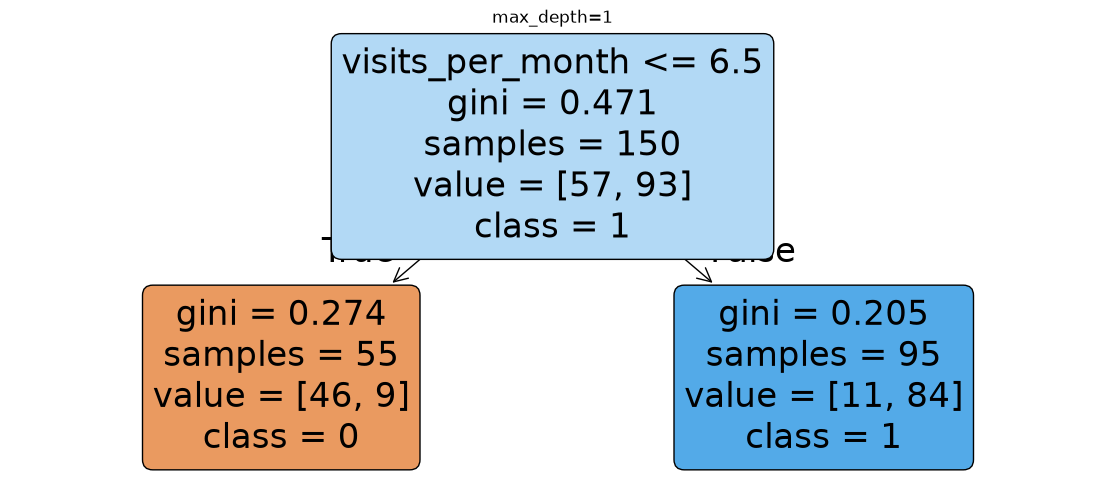

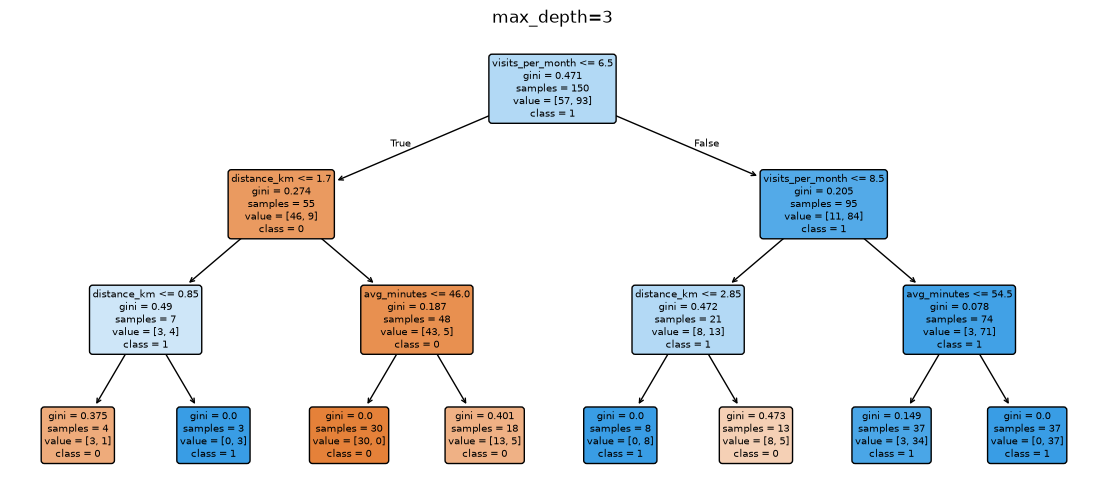

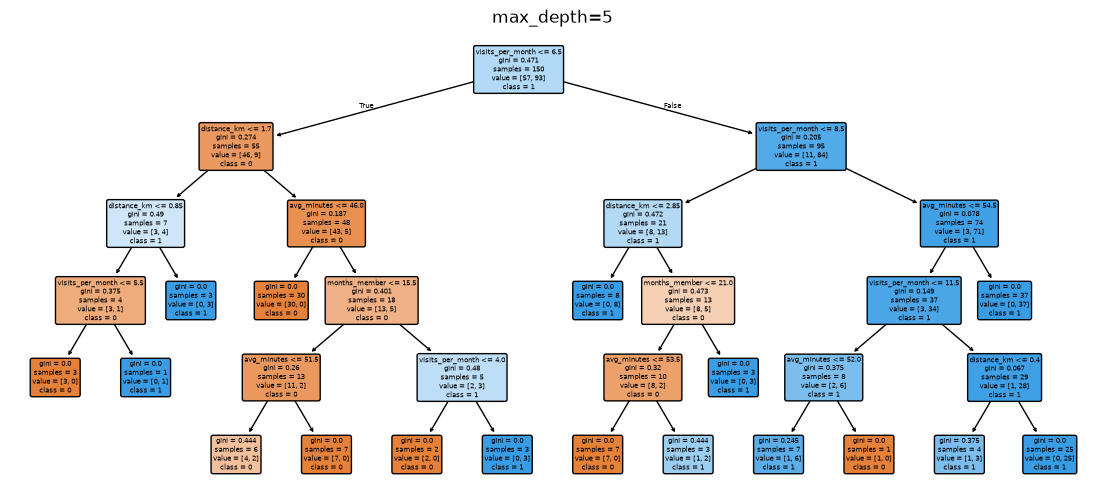

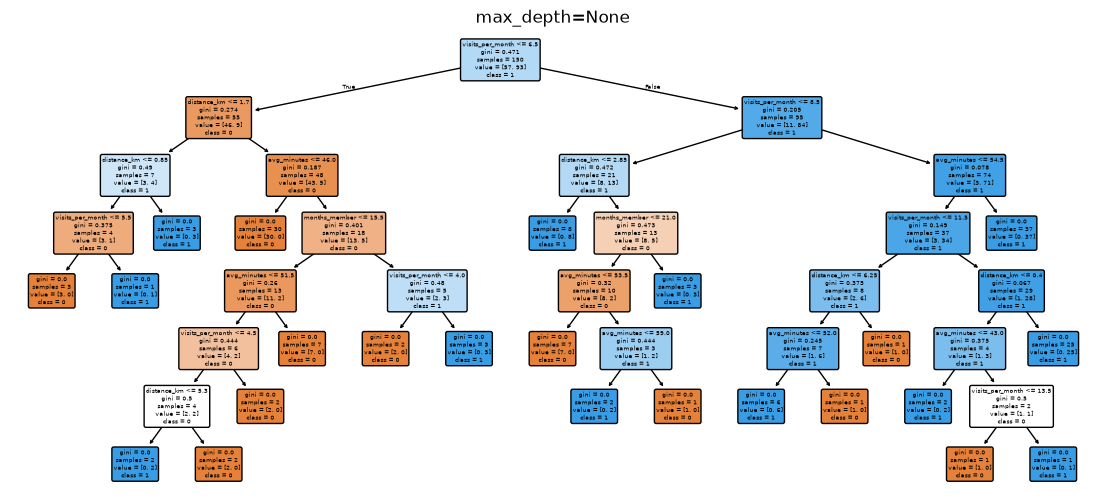

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

[
    (
        plt.figure(figsize=(14, 6)),
        plot_tree(
            DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(
                X_train, y_train
            ),
            feature_names=feature_cols,
            class_names=["0", "1"],
            filled=True,
            rounded=True,
        ),
        plt.title(f"max_depth={d}"),
        plt.show(),
    )
    for d in depths
];


# Part 3 · Accuracy hides what kind of mistake
Accuracy is one number: the share of members you labelled correctly. It cannot tell you **which** members you got wrong, and the gym cares about that.

The **confusion matrix** splits the answers into four boxes. In scikit-learn the layout is:

|  | predicted 0 | predicted 1 |
|---|---|---|
| **actually 0** | TN | FP |
| **actually 1** | FN | TP |

For "will this member renew?", with renewed = 1:
- **TP:** we said renew, they renewed.
- **TN:** we said leave, they left.
- **FP:** we said renew, they left. The gym counted on money that never came.
- **FN:** we said leave, they renewed. The gym may have wasted a discount offer on someone who was staying anyway.

Three numbers read the matrix for you:

| Metric | Formula | Plain question |
|---|---|---|
| **Precision** | TP / (TP + FP) | When we say "renew", how often are we right? |
| **Recall** | TP / (TP + FN) | Of the members who really renewed, how many did we find? |
| **F1** | the balance of the two | One number when you care about both |

### E2 · Confusion matrix for the tree and for KNN
**Predict:** the tree and KNN score within a few points of each other. Do you expect them to get the *same* members wrong?

*Your answer:* No, while they mainly get the same ones correct, there will be some one gets right that the other gets wrong

In [24]:
best_tree = None
tree_pred = knn_pred = None
scores = None

ready(best_depth, "E1")  # prints a reminder if E1 is not done

# Write your code below. Your code must create the variables set to None above.

# 1. best_tree: a DecisionTreeClassifier with max_depth=best_depth, random_state=RANDOM_STATE,
#    fitted on the training rows.
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE).fit(
    X_train, y_train
)

# 2. tree_pred and knn_pred: the predictions of best_tree and of knn_model on X_test.
#    Hint: model.predict(X_test)
tree_pred, knn_pred = best_tree.predict(X_test), knn_model.predict(X_test)

# 3. scores: a DataFrame with one row per model (call them "tree" and "knn") and these columns:
#       accuracy, precision, recall, f1
#    Hint: accuracy_score(y_test, pred), precision_score(y_test, pred), recall_score, f1_score
scores = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_test, p),
            "precision": precision_score(y_test, p),
            "recall": recall_score(y_test, p),
            "f1": f1_score(y_test, p),
        }
        for p in (tree_pred, knn_pred)
    ],
    index=["tree", "knn"],
)
# 4. Display scores, and display confusion_matrix(y_test, tree_pred) and
#    confusion_matrix(y_test, knn_pred). The layout is [[TN, FP], [FN, TP]].
display(scores)
display(confusion_matrix(y_test, tree_pred))
display(confusion_matrix(y_test, knn_pred))


,accuracy,precision,recall,f1
tree,0.86,0.900000,0.870968,0.885246
knn,0.90,0.964286,0.870968,0.915254


array([[16,  3],
       [ 4, 27]])

array([[18,  1],
       [ 4, 27]])

**Check E2**

In [25]:
if ready(best_tree, "E2"):
    check(
        "best_tree uses the depth chosen by cross-validation",
        best_tree.max_depth == best_depth,
    )
    check(
        "predictions were made on the test rows",
        len(tree_pred) == len(y_test) and len(knn_pred) == len(y_test),
    )
    check("scores holds both models", len(scores) == 2)
    check(
        "scores reports accuracy, precision, recall, and f1",
        set(scores.columns) >= {"accuracy", "precision", "recall", "f1"},
    )
    check(
        "the accuracy in the table is the real score of the tree",
        np.isclose(scores.loc["tree", "accuracy"], accuracy_score(y_test, tree_pred)),
    )
    check(
        "the four boxes of the tree matrix add up to the test rows",
        confusion_matrix(y_test, tree_pred).sum() == len(y_test),
    )

PASS  best_tree uses the depth chosen by cross-validation
PASS  predictions were made on the test rows
PASS  scores holds both models
PASS  scores reports accuracy, precision, recall, and f1
PASS  the accuracy in the table is the real score of the tree
PASS  the four boxes of the tree matrix add up to the test rows


In [26]:
if ready(tree_pred, "E2"):
    comparison = pd.DataFrame(
        {
            "member_id": members.loc[X_test.index, "member_id"],
            "actually_renewed": y_test,
            "tree_says": tree_pred,
            "knn_says": knn_pred,
        }
    )
    disagree = comparison[comparison["tree_says"] != comparison["knn_says"]]
    print("Members the two models label differently:", len(disagree))
    display(disagree)

Members the two models label differently: 6


,member_id,actually_renewed,tree_says,knn_says
24,M025,1,1,0
28,M029,0,1,0
93,M094,1,0,1
184,M185,0,1,0
196,M197,1,0,1
138,M139,1,1,0


**Write:** look at the two matrices. Which model would you give the gym manager, and what does it cost the gym when it is wrong?

*Your answer:*

**I would give the gym manager the knn model. It gives the most accurate results. KNN is less likely to give a false positive**

# Part 4 · When accuracy lies
New table, same gym. Over the last year, some members asked for a refund. The manager wants to spot them early, so the front desk can call.

Refund requests are **rare**: about 8 in every 100 members. That changes everything about accuracy.

In [27]:
refund_rng = np.random.default_rng(5)
n_refund = 800
refund_requested = refund_rng.binomial(1, 0.08, n_refund)

refunds = pd.DataFrame(
    {
        "member_id": [f"R{i:03d}" for i in range(1, n_refund + 1)],
        "visits_per_month": np.where(
            refund_requested == 1,
            np.clip(refund_rng.normal(5, 3, n_refund), 0, None),
            np.clip(refund_rng.normal(8.5, 4, n_refund), 0, None),
        )
        .round()
        .astype(int),
        "complaints": np.where(
            refund_requested == 1,
            refund_rng.poisson(1.2, n_refund),
            refund_rng.poisson(0.55, n_refund),
        ),
        "days_since_signup": np.where(
            refund_requested == 1,
            refund_rng.integers(10, 200, n_refund),
            refund_rng.integers(15, 400, n_refund),
        ),
        "refund_requested": refund_requested,
    }
)

refund_features = ["visits_per_month", "complaints", "days_since_signup"]
print(refunds["refund_requested"].value_counts().to_dict())
print("Share who asked for a refund:", round(refunds["refund_requested"].mean(), 3))
display(refunds.head())

{0: 737, 1: 63}
Share who asked for a refund: 0.079


,member_id,visits_per_month,complaints,days_since_signup,refund_requested
0,R001,3,0,288,0
1,R002,11,2,385,0
2,R003,10,0,170,0
3,R004,8,0,369,0
4,R005,5,2,29,0


**Predict:** a model that simply answers "no refund" for every single member. What is its accuracy, and how many refund requests does it catch?

*Your prediction:* I would give it an accuracy of ~85%. since most of the members do not ask for a refund

### E3 · Two models on the refund data
Model A answers "no" to everybody. Model B is a tree that has been told to take the rare class seriously (`class_weight="balanced"` makes each refund request count as much as about eleven non-requests).

In [28]:
Xr_train = Xr_test = yr_train = yr_test = None
model_a = model_b = None
refund_scores = None

# Write your code below. Your code must create the variables set to None above.

# 1. Split the refunds features and target the same way as always:
#    test_size=0.25, random_state=RANDOM_STATE, stratify the target.
#    Name them Xr_train, Xr_test, yr_train, yr_test.
#    Hint: refunds[refund_features] and refunds["refund_requested"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    refunds[refund_features],
    refunds["refund_requested"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=refunds["refund_requested"],
)

# 2. model_a: a DummyClassifier(strategy="most_frequent") fitted on the training rows.
#    This is the "nobody asks for a refund" model.
model_a = DummyClassifier(strategy="most_frequent").fit(Xr_train, yr_train)

# 3. model_b: DecisionTreeClassifier(max_depth=3, class_weight="balanced",
#    random_state=RANDOM_STATE) fitted on the training rows.
model_b = DecisionTreeClassifier(
    max_depth=3, class_weight="balanced", random_state=RANDOM_STATE
).fit(Xr_train, yr_train)

# 4. refund_scores: a DataFrame with one row per model ("A" and "B") and the columns
#    accuracy, precision, recall. Use precision_score(..., zero_division=0).
refund_scores = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(yr_test, p := m.predict(Xr_test)),
            "precision": precision_score(yr_test, p, zero_division=0),
            "recall": recall_score(yr_test, p),
        }
        for m in (model_a, model_b)
    ],
    index=["A", "B"],
)

# 5. Display refund_scores, and the confusion matrix of each model.
display(
    refund_scores,
    confusion_matrix(yr_test, model_a.predict(Xr_test)),
    confusion_matrix(yr_test, model_b.predict(Xr_test)),
)

,accuracy,precision,recall
A,0.92,0.000000,0.0000
B,0.81,0.270833,0.8125


array([[184,   0],
       [ 16,   0]])

array([[149,  35],
       [  3,  13]])

**Check E3**

In [29]:
if ready(model_a, "E3"):
    check(
        "the refund split is stratified, so both parts hold refund requests",
        yr_test.sum() > 0,
    )
    check(
        "model A predicts the same class for everybody",
        len(set(model_a.predict(Xr_test))) == 1,
    )
    check(
        "refund_scores holds both models with accuracy, precision, recall",
        len(refund_scores) == 2
        and set(refund_scores.columns) >= {"accuracy", "precision", "recall"},
    )
    check("model A has high accuracy", refund_scores.loc["A", "accuracy"] > 0.9)
    check(
        "model A finds none of the refund requests",
        np.isclose(refund_scores.loc["A", "recall"], 0.0),
    )
    check("model B finds most of them", refund_scores.loc["B", "recall"] > 0.8)

PASS  the refund split is stratified, so both parts hold refund requests
PASS  model A predicts the same class for everybody
PASS  refund_scores holds both models with accuracy, precision, recall
PASS  model A has high accuracy
PASS  model A finds none of the refund requests
PASS  model B finds most of them


**Write:** model A is right about 92% of the time. Write one sentence you would say to the gym manager about model A.

*Your answer:* Even though it is mostly accurate, if everyone asks for a refund it would have a 0% accuracy. 

# Part 5 · Put money on the errors, then answer the AI
Metrics do not choose for you. The costs do.

For the gym: a refund request the model misses costs about **$40** (the refund, plus a member who leaves unhappy). A call to a member who was never going to ask costs about **$2** of front-desk time.

In [30]:
COST_MISSED = 40  # dollars lost per refund request we failed to flag
COST_CALL = 2  # dollars of staff time per call

print("Model A calls nobody. Model B calls everybody it flags, right or wrong.")

Model A calls nobody. Model B calls everybody it flags, right or wrong.


### E4 · The cost table

In [31]:
cost_table = None

ready(model_b, "E3")  # prints a reminder if E3 is not done

# Write your code below. Your code must create the variable set to None above.

# 1. For each model, pull TP, FP, FN, TN out of its confusion matrix on the refund test rows.
#    Hint: tn, fp, fn, tp = confusion_matrix(yr_test, model.predict(Xr_test)).ravel()
tn, fp, fn, tp = confusion_matrix(yr_test, model_b.predict(Xr_test)).ravel()

# 2. cost_table: a DataFrame with one row per model ("A" and "B") and these columns:
#       missed_refunds (FN), calls_made (FP + TP), total_cost
cost_table = pd.DataFrame(
    [
        {
            "missed_refunds": fn,
            "calls_made": fp + tp,
            "total_cost": fn * COST_MISSED + (fp + tp) * COST_CALL,
        }
        for tn, fp, fn, tp in (
            confusion_matrix(yr_test, m.predict(Xr_test)).ravel()
            for m in (model_a, model_b)
        )
    ],
    index=["A", "B"],
)

# 3. Display cost_table next to refund_scores.
display(cost_table, refund_scores)

,missed_refunds,calls_made,total_cost
A,16,0,640
B,3,48,216


,accuracy,precision,recall
A,0.92,0.000000,0.0000
B,0.81,0.270833,0.8125


**Check E4**

In [32]:
if ready(cost_table, "E4"):
    check("cost_table holds both models", len(cost_table) == 2)
    check(
        "it reports missed refunds, calls made, and total cost",
        set(cost_table.columns) >= {"missed_refunds", "calls_made", "total_cost"},
    )
    check("model A makes no calls", cost_table.loc["A", "calls_made"] == 0)
    check(
        "the totals use the two costs at the top of this part",
        cost_table.loc["B", "total_cost"]
        == cost_table.loc["B", "missed_refunds"] * COST_MISSED
        + cost_table.loc["B", "calls_made"] * COST_CALL,
    )
    check(
        "the model with the higher accuracy is the more expensive one",
        cost_table.loc["A", "total_cost"] > cost_table.loc["B", "total_cost"],
    )

PASS  cost_table holds both models
PASS  it reports missed refunds, calls made, and total cost
PASS  model A makes no calls
PASS  the totals use the two costs at the top of this part
PASS  the model with the higher accuracy is the more expensive one


**Write:** an AI assistant says *"Model A has 92% accuracy and model B has 75%, so model A is the better model."* Answer it in three or four sentences, using the confusion matrices and the cost table.

*Your answer:* Using accuracy in this case is incorrect, the model misses 100% of the refund requests. Each request missed costs money. However, model B catches the most refund requests-saving a significant amount of money compared to model a

### Challenge tasks (optional)
1. Change `COST_CALL` until model A becomes the cheaper model. What price makes the two equal?
2. Refit model B without `class_weight="balanced"`. What happens to its recall, and why?
3. Print the tree rules for model B with `export_text`. Which feature does it ask about first?

# Exit ticket
Answer without running more code.
1. A model has accuracy 0.92 and recall 0.00 on refund requests. Explain in one sentence what it is doing.
2. Your tree has training accuracy 1.00 and cross-validation accuracy 0.79. What is wrong, and what would you change?
3. Give one situation where a false positive is worse than a false negative, and one where it is the other way round.

*Your answers:*
1. The model is selecting the same answer for every request no matter what
2. The tree is overfitting data. we should lower the max depth.
3. For a false positive, sending an important email to spam instead of the inbox. For false negative, test results in a lab (cancer, covid, other illnesses) would cause significant changes in how a patient is treated. 

# Submit
- Restart the kernel and run all cells. Every check should print `PASS`.
- Every *Your answer* and *Your prediction* cell is filled in.
- Submit this notebook with its outputs.